# Planning course graded exercice #2

This exercice will give you a glimpse into near-realistic flight planning with the open source aircraft performance model [openap](https://openap.dev/).

First, we get the main imports of the notebook from scikit-decide since openap is provided as a flight planning domain in scikit-decide.

In [ ]:
# import datetime

import numpy as np
from openap.extra.aero import cas2mach, ft, kts
from openap.extra.nav import airport
from pygeodesy.ellipsoidalVincenty import LatLon

from skdecide.hub.domain.flight_planning.aircraft_performance.bean.aircraft_state import (
    AircraftState,
)
from skdecide.hub.domain.flight_planning.aircraft_performance.performance.performance_model_enum import (
    PerformanceModelEnum,
)
from skdecide.hub.domain.flight_planning.aircraft_performance.performance.phase_enum import (
    PhaseEnum,
)
from skdecide.hub.domain.flight_planning.aircraft_performance.performance.rating_enum import (
    RatingEnum,
)
from skdecide.hub.domain.flight_planning.domain import FlightPlanningDomain, WeatherDate
from skdecide.hub.domain.flight_planning.flightplanning_utils import (
    plot_network_adapted,
)
from skdecide.hub.solver.astar import Astar

First, we set the date for the weather data to today. You can change the day if you remember a recent stormy day..

In [6]:
today = datetime.date.today()
weather_date = None
print(weather_date)

None


We then define the aircraft state, which includes the aircraft performance model -- in this case a A320 aircraft.

We assume the aircraft is flying at 10000 feet at 250 knots and is weighting 80 tons.

In [7]:
acState = AircraftState(
    model_type="A320",  # only for OPENAP and POLL_SCHUMANN
    performance_model_type=PerformanceModelEnum.POLL_SCHUMANN,  # PerformanceModelEnum.OPENAP
    gw_kg=80_000,
    zp_ft=10_000,
    mach=cas2mach(250 * kts, h=10_000 * ft),
    phase=PhaseEnum.CLIMB,
    rating_level=RatingEnum.MCL,
    cg=0.3,
)

We now define the flight planning domain, optimizing for fuel burn minimization. Other options are distance and time minimization.

The heuristic function is used by the A\* solver, it can be one of 'time', 'distance', 'lazy_fuel', 'lazy_time' or None, in which case the heuristic value will be the constant 0.

In [8]:
domain_factory = lambda: FlightPlanningDomain(
    aircraft_state=acState,
    mach_cruise=0.78,
    mach_climb=0.7,
    mach_descent=0.65,
    nb_forward_points=20,
    nb_lateral_points=10,
    nb_climb_descent_steps=5,
    flight_levels_ft=list(np.arange(30_000, 38_000 + 2_000, 2_000)),
    graph_width="medium",
    origin="LFBO",
    destination="EDDB",
    objective="fuel",
    heuristic_name="lazy_fuel",
    weather_date=weather_date,
)

domain = domain_factory()

d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


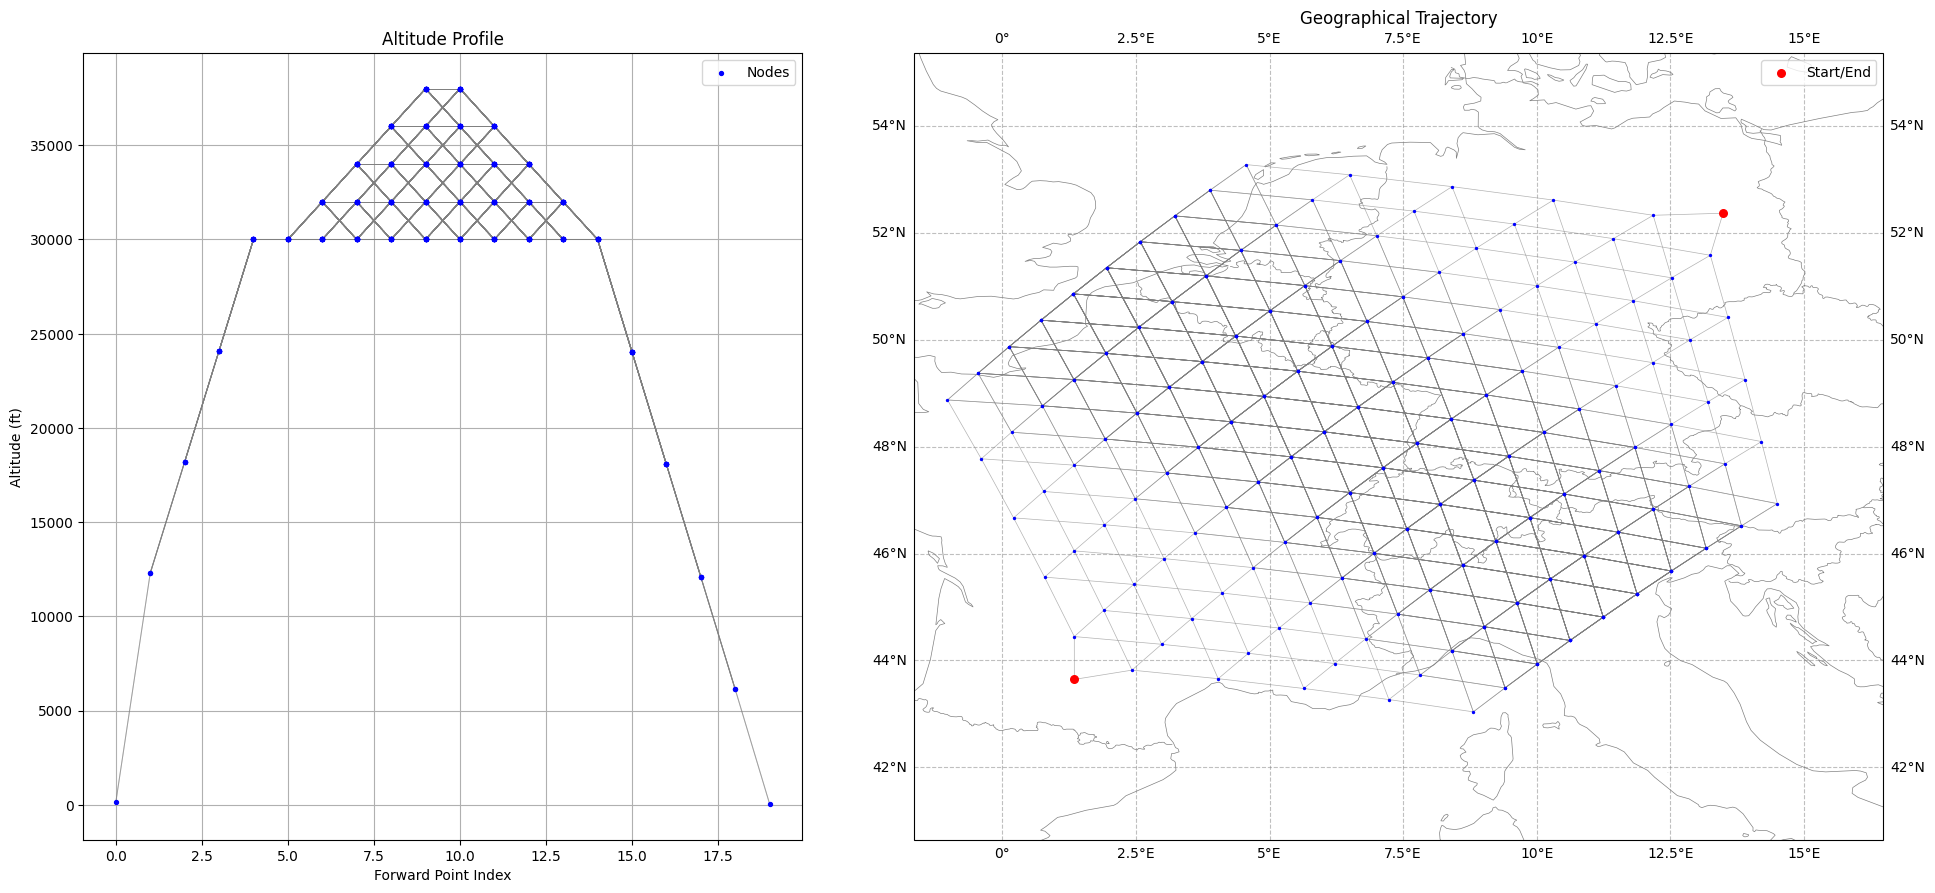

In [9]:
plot_network_adapted(
    graph=domain.network,
    p0=LatLon(
        airport("LFBO")["lat"], airport("LFBO")["lon"], airport("LFBO")["alt"] * ft
    ),
    p1=LatLon(
        airport("EDDB")["lat"], airport("EDDB")["lon"], airport("EDDB")["alt"] * ft
    ),
)

Let's solve the problem with the A\* algorithm from scikit-decide.

Final state reached


d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


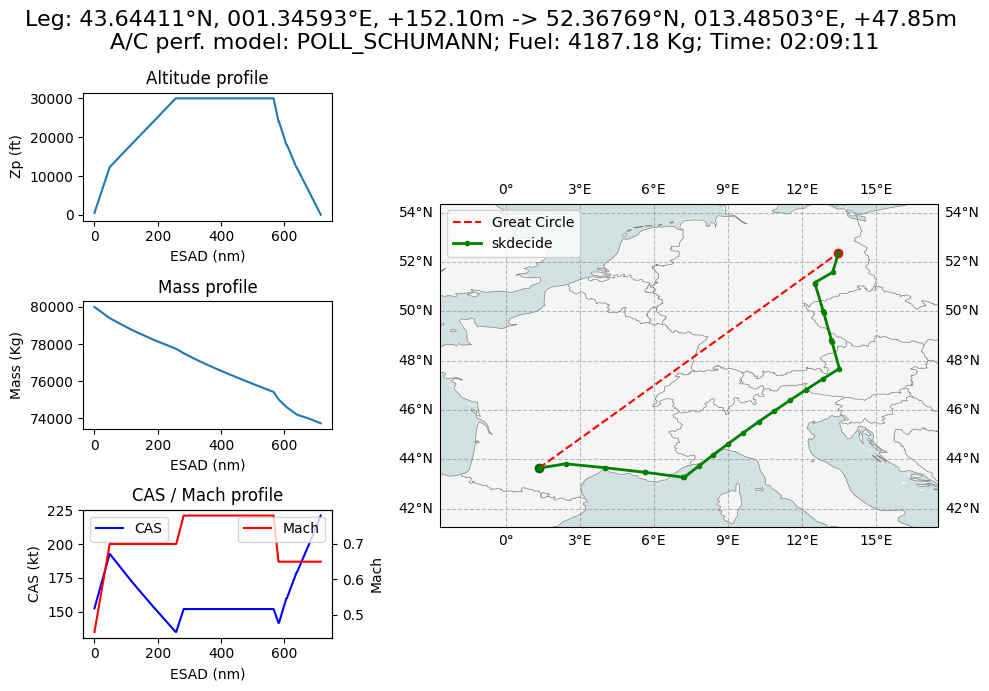

Goal reached after 19 steps!


In [10]:
with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)

Optimize for distance and time too, and compare the resulting trajectory and profiles with the ones obtained when minimizing the fuel.

***
Optimising for time

In [11]:
### YOUR TURN ### update the heuristic to distance or time heuristic from fuel heuristic

domain_factory = lambda: FlightPlanningDomain(
    aircraft_state=acState,
    mach_cruise=0.78,
    mach_climb=0.7,
    mach_descent=0.65,
    nb_forward_points=20,
    nb_lateral_points=10,
    nb_climb_descent_steps=5,
    flight_levels_ft=list(np.arange(30_000, 38_000 + 2_000, 2_000)),
    graph_width="medium",
    origin="LFBO",
    destination="EDDB",
    objective="fuel",
    heuristic_name="time",
    weather_date=weather_date,
)

domain = domain_factory()

Final state reached


d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


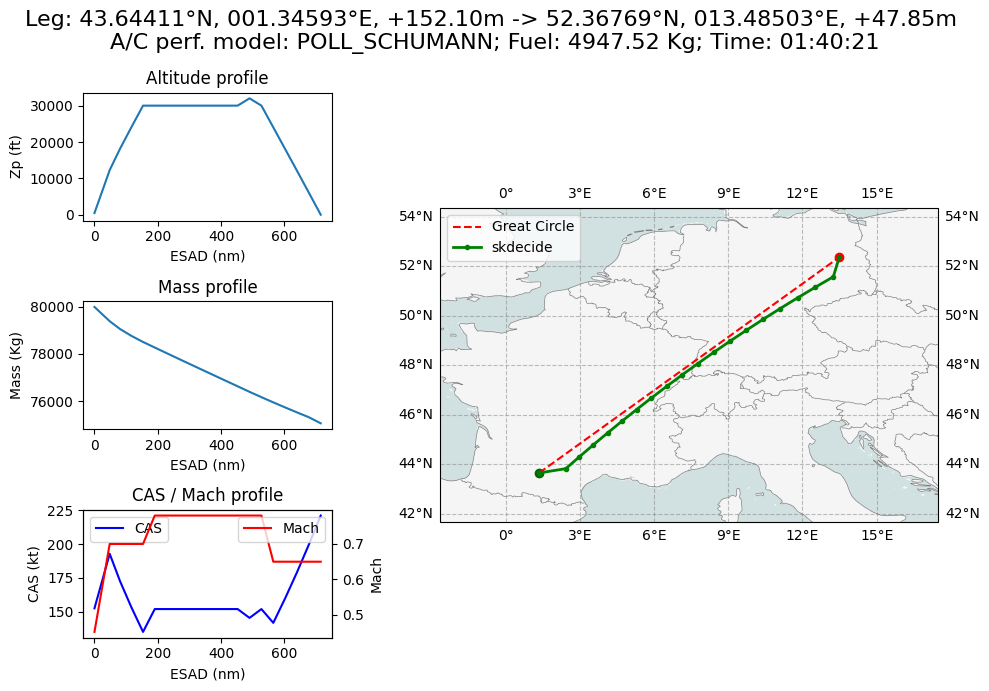

Goal reached after 19 steps!


In [12]:
with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)

Final state reached


d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


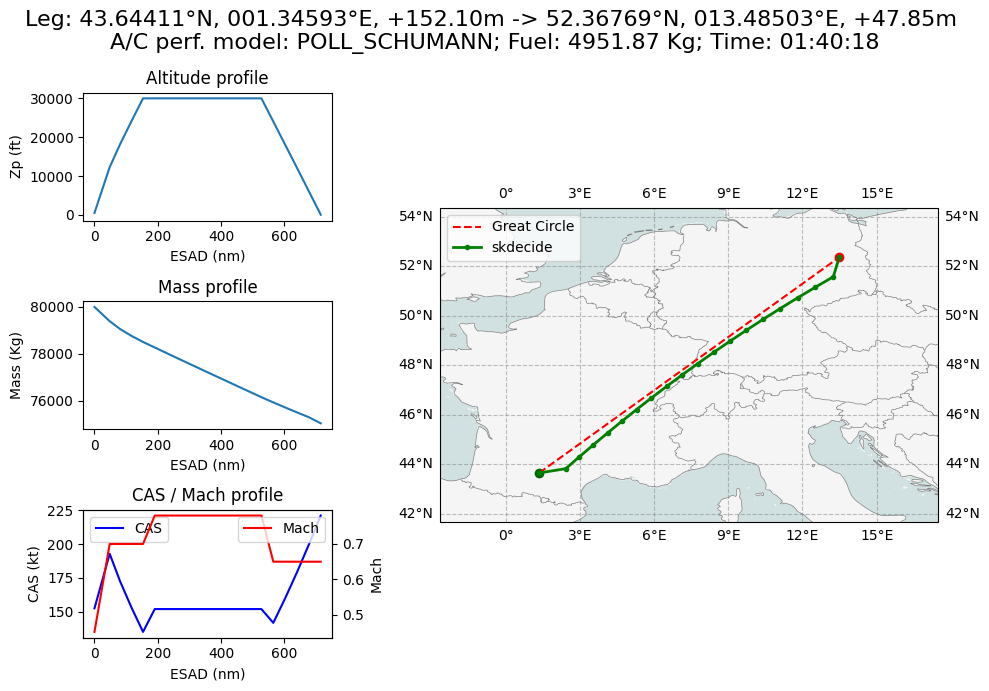

Goal reached after 19 steps!


In [18]:
with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)

***
Optimising for distance

In [13]:
domain_factory = lambda: FlightPlanningDomain(
    aircraft_state=acState,
    mach_cruise=0.78,
    mach_climb=0.7,
    mach_descent=0.65,
    nb_forward_points=20,
    nb_lateral_points=10,
    nb_climb_descent_steps=5,
    flight_levels_ft=list(np.arange(30_000, 38_000 + 2_000, 2_000)),
    graph_width="medium",
    origin="LFBO",
    destination="EDDB",
    objective="fuel",
    heuristic_name="distance",
    weather_date=weather_date,
)

domain = domain_factory()

Final state reached


d:\Chris\Documents\Uni_docs\ISAE\AIBT108 - Reinforcement Learning and Planning\aibt_108\.venv\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


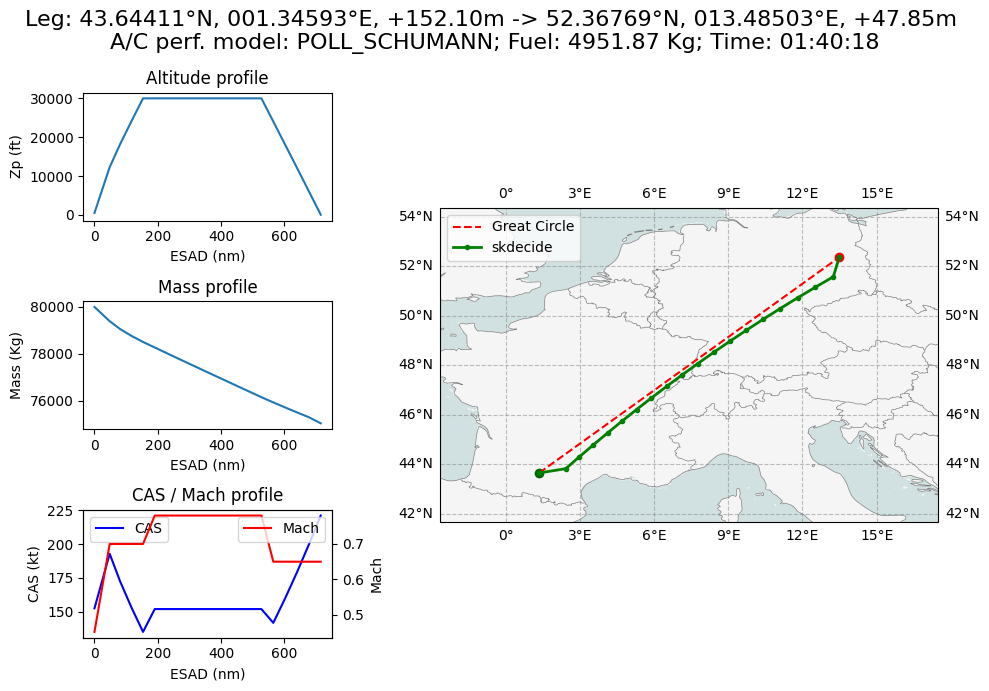

Goal reached after 19 steps!


In [14]:
with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)

***
Study the impact of aircraft weight, altitude and speed on the resulting trajectory and profiles.

In [ ]:
### YOUR TURN ###
acState = AircraftState(
    model_type="A320",  # only for OPENAP and POLL_SCHUMANN
    performance_model_type=PerformanceModelEnum.POLL_SCHUMANN,  # PerformanceModelEnum.OPENAP
    gw_kg=80_000,
    zp_ft=10_000,
    mach=cas2mach(250 * kts, h=10_000 * ft),
    phase=PhaseEnum.CLIMB,
    rating_level=RatingEnum.MCL,
    cg=0.3,
)

In [ ]:
domain_factory = lambda: FlightPlanningDomain(
    aircraft_state=acState,
    mach_cruise=0.78,
    mach_climb=0.7,
    mach_descent=0.65,
    nb_forward_points=20,
    nb_lateral_points=10,
    nb_climb_descent_steps=5,
    flight_levels_ft=list(np.arange(30_000, 38_000 + 2_000, 2_000)),
    graph_width="medium",
    origin="LFBO",
    destination="EDDB",
    objective="fuel",
    heuristic_name="time",
    weather_date=weather_date,
)

domain = domain_factory()

In [ ]:
with Astar(
    domain_factory=domain_factory,
    heuristic=lambda d, s: d.heuristic(s),
    parallel=False,
) as solver:
    solver.solve()
    domain.custom_rollout(solver=solver, make_img=True)